In [1]:
# ============================================
# LOAD CLEAN DATASET
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"data/processed/flights_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

print("Dataset Loaded:", df.shape)

Dataset Loaded: (3000000, 38)


In [2]:
# ============================================
# RESTORE CATEGORY TYPES
# ============================================

categorical_cols = [
"AIRLINE",
"AIRLINE_DOT",
"AIRLINE_CODE",
"ORIGIN",
"ORIGIN_CITY",
"DEST",
"DEST_CITY",
"CANCELLATION_CODE",
"ROUTE",
"DAY_OF_WEEK"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

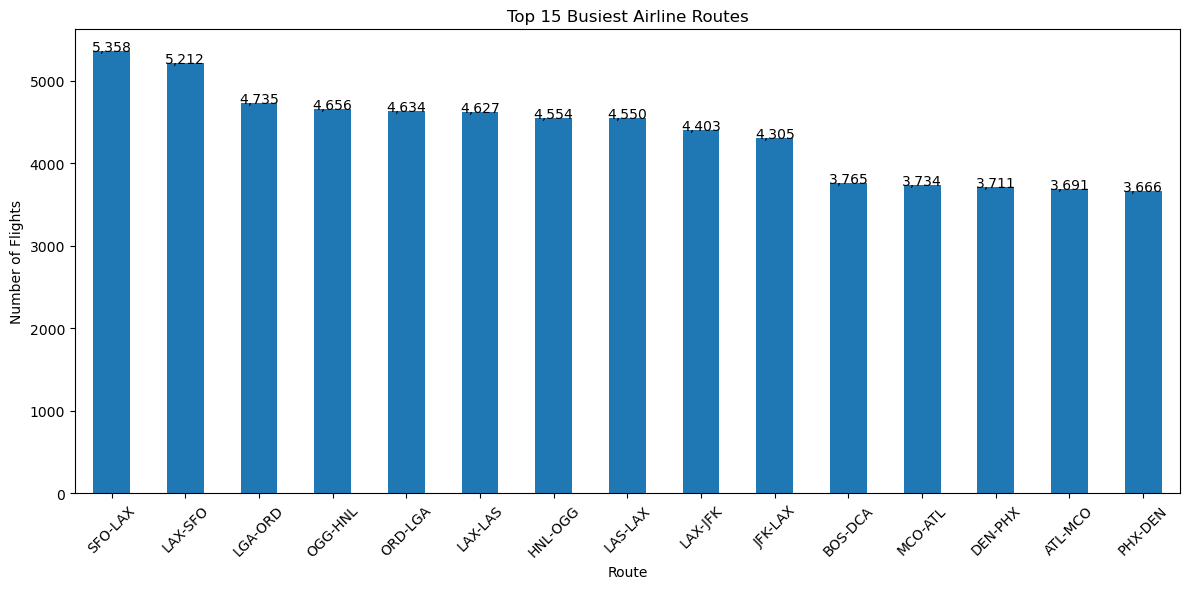

In [3]:
# ============================================
# BUSIEST ROUTES
# ============================================

top_routes = df["ROUTE"].value_counts().head(15)

plt.figure(figsize=(12,6))

ax = top_routes.plot(kind="bar")

plt.title("Top 15 Busiest Airline Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

for i,v in enumerate(top_routes):
    ax.text(i,v,f"{v:,}",ha="center")

plt.tight_layout()
plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_34600\2992324044.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_delay = df.groupby("DISTANCE_GROUP")["ARR_DELAY"].mean()


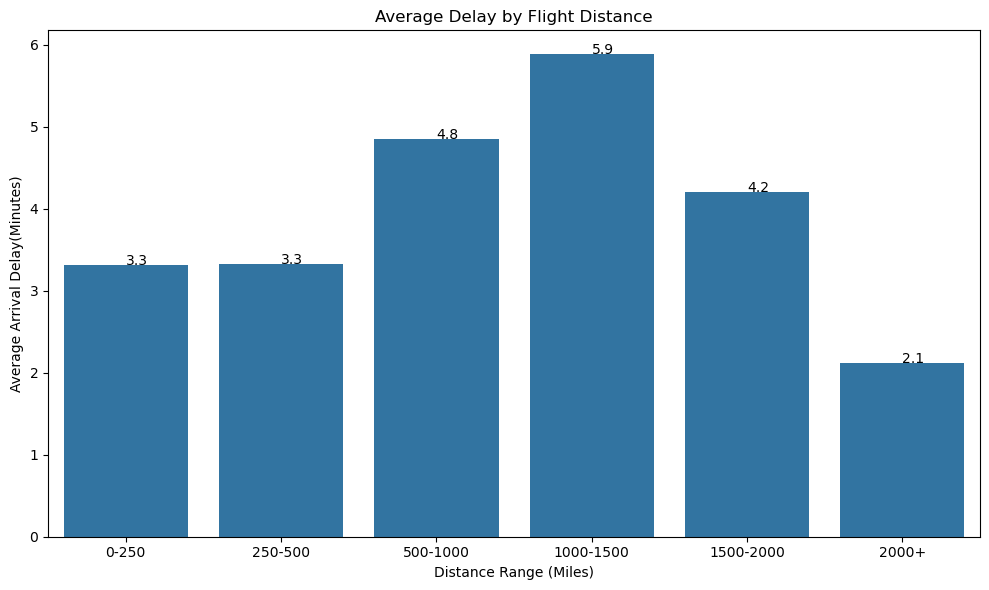

In [13]:
# ============================================
# DISTANCE BIN ANALYSIS
# ============================================

bins = [0,250,500,1000,1500,2000,3000]
labels = [
"0-250",
"250-500",
"500-1000",
"1000-1500",
"1500-2000",
"2000+"
]

df["DISTANCE_GROUP"] = pd.cut(df["DISTANCE"],bins=bins,labels=labels)

distance_delay = df.groupby("DISTANCE_GROUP")["ARR_DELAY"].mean()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=distance_delay.index,
    y=distance_delay.values
)

plt.title("Average Delay by Flight Distance")
plt.xlabel("Distance Range (Miles)")
plt.ylabel("Average Arrival Delay(Minutes)")

for i,v in enumerate(distance_delay):
    plt.text(i,v,f"{v:.1f}")

plt.tight_layout()
plt.show()

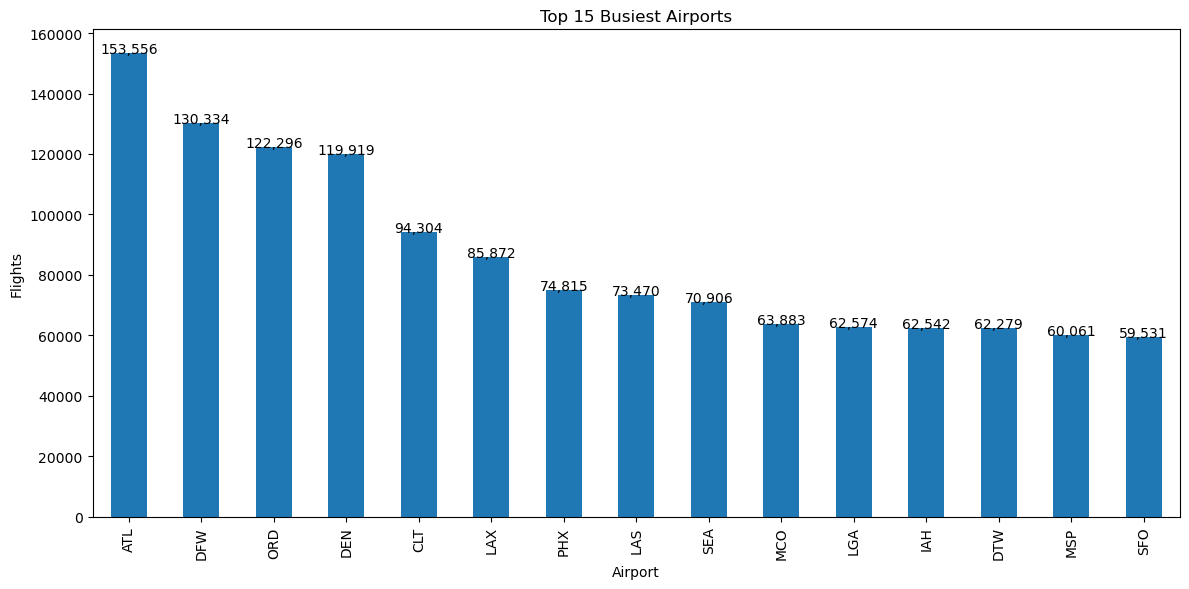

In [6]:
# ============================================
# BUSIEST AIRPORTS
# ============================================

airport_traffic = df["ORIGIN"].value_counts().head(15)

plt.figure(figsize=(12,6))

ax = airport_traffic.plot(kind="bar")

plt.title("Top 15 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Flights")

for i,v in enumerate(airport_traffic):
    ax.text(i,v,f"{v:,}",ha="center")

plt.tight_layout()
plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_34600\1102680013.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airport_delay = df.groupby("ORIGIN")["ARR_DELAY"].mean()


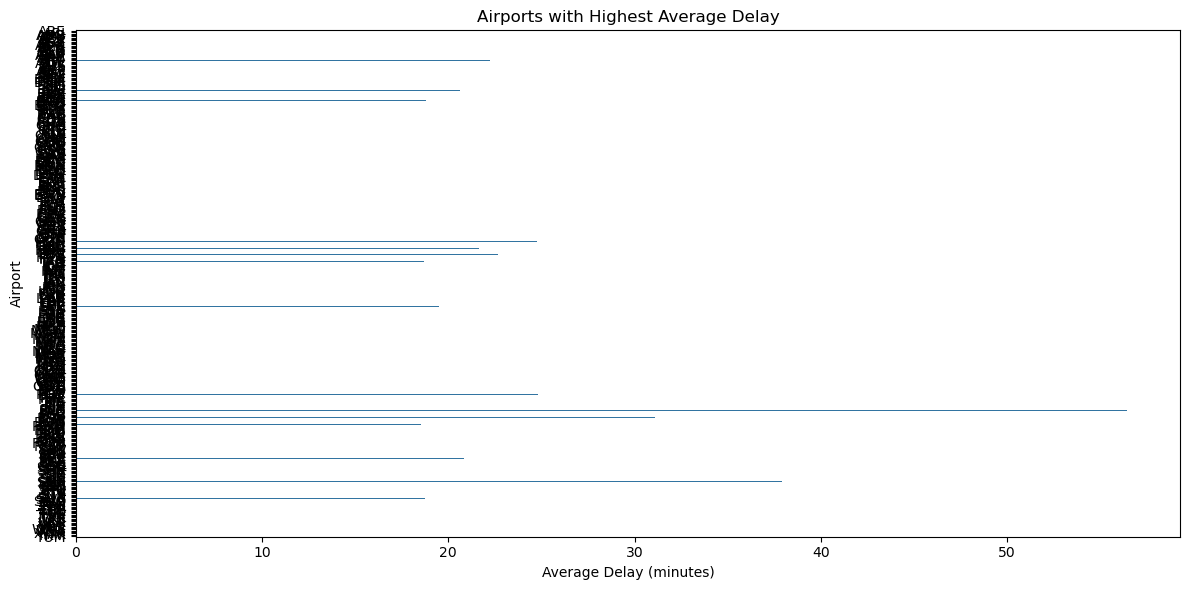

In [7]:
# ============================================
# AIRPORT DELAY ANALYSIS
# ============================================

airport_delay = df.groupby("ORIGIN")["ARR_DELAY"].mean()

top_delay_airports = airport_delay.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
x=top_delay_airports.values,
y=top_delay_airports.index
)

plt.title("Airports with Highest Average Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airport")

plt.tight_layout()
plt.show()

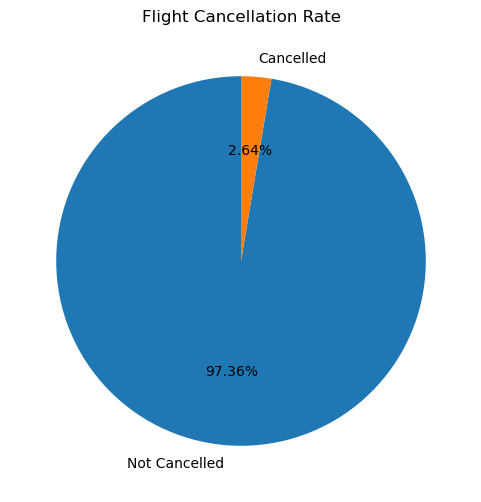

In [8]:
# ============================================
# CANCELLATION RATE
# ============================================

cancel_rate = df["CANCELLED"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
cancel_rate,
labels=["Not Cancelled","Cancelled"],
autopct="%1.2f%%",
startangle=90
)

plt.title("Flight Cancellation Rate")

plt.show()

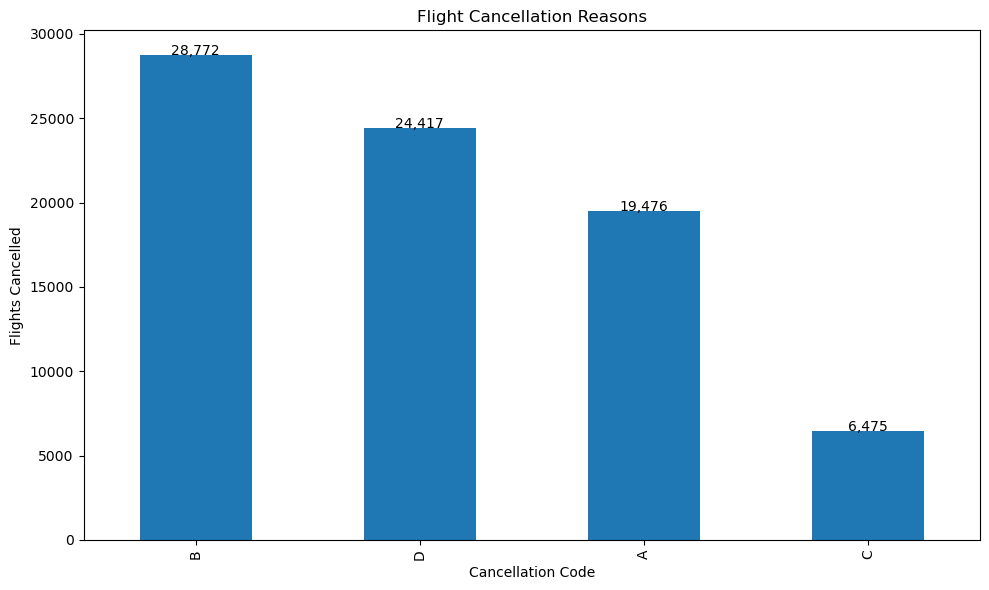

In [9]:
# ============================================
# CANCELLATION REASONS
# ============================================

cancel_reasons = df[df["CANCELLED"]==1]["CANCELLATION_CODE"].value_counts()

plt.figure(figsize=(10,6))

ax = cancel_reasons.plot(kind="bar")

plt.title("Flight Cancellation Reasons")
plt.xlabel("Cancellation Code")
plt.ylabel("Flights Cancelled")

for i,v in enumerate(cancel_reasons):
    ax.text(i,v,f"{v:,}",ha="center")

plt.tight_layout()
plt.show()

| Code | Meaning  |
| ---- | -------- |
| A    | Carrier  |
| B    | Weather  |
| C    | NAS      |
| D    | Security |


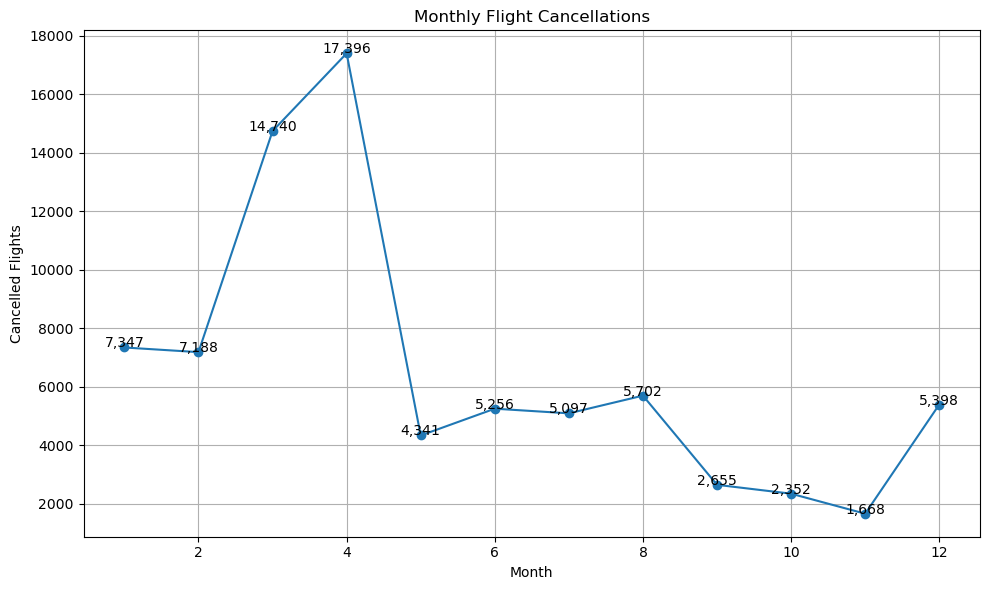

In [16]:
# ============================================
# MONTHLY CANCELLATION TREND
# ============================================

monthly_cancel = df[df["CANCELLED"]==1].groupby("MONTH").size()

plt.figure(figsize=(10,6))

ax = monthly_cancel.plot(marker="o")

plt.title("Monthly Flight Cancellations")
plt.xlabel("Month")
plt.ylabel("Cancelled Flights")

for i,v in enumerate(monthly_cancel):
    ax.text(i+1,v,f"{v:,}",ha="center")

plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_34600\2640614508.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cancel_heat = df[df["CANCELLED"]==1].pivot_table(


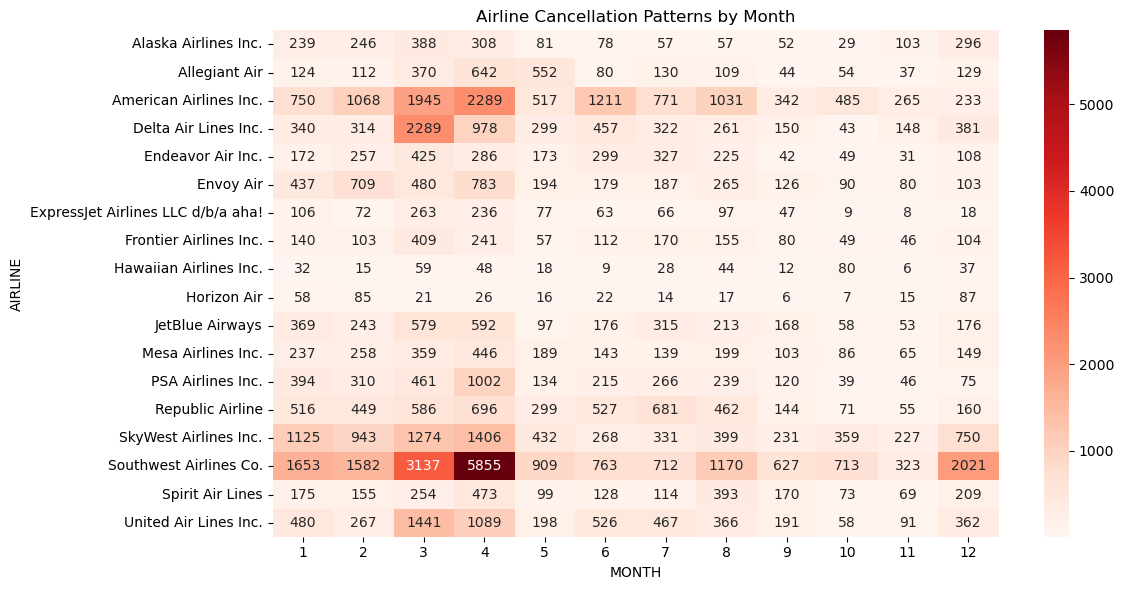

In [17]:
# ============================================
# CANCELLATION HEATMAP
# ============================================

cancel_heat = df[df["CANCELLED"]==1].pivot_table(
index="AIRLINE",
columns="MONTH",
values="CANCELLED",
aggfunc="count"
)

plt.figure(figsize=(12,6))

sns.heatmap(
cancel_heat,
cmap="Reds",
annot=True,
fmt=".0f"
)

plt.title("Airline Cancellation Patterns by Month")

plt.tight_layout()

plt.show()